# MSCS-634 Advanced Big Data and Data Mining

## Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python

**Name:** Minh Le  
**Course:** MSCS-634 Advanced Big Data and Data Mining  
**Assignment:** Lab 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
np.random.seed(42)

## Step 1: Data Collection

For this lab, a synthetic sales dataset was created to demonstrate data visualization, preprocessing, and statistical analysis techniques.

In [2]:
n = 100

data = {
    "Date": pd.date_range(start="2026-01-01", periods=n, freq="D"),
    "Product": np.random.choice(
        ["Laptop", "Phone", "Tablet", "Monitor", "Headphones"], n
    ),
    "Category": np.random.choice(
        ["Computers", "Mobile", "Accessories"], n
    ),
    "Region": np.random.choice(
        ["West", "East", "North", "South"], n
    ),
    "Units_Sold": np.random.randint(1, 30, n),
    "Unit_Price": np.round(np.random.uniform(50, 1500, n), 2),
    "Customer_Rating": np.round(np.random.uniform(2.5, 5.0, n), 1),
    "Discount": np.round(np.random.uniform(0, 0.30, n), 2)
}

df = pd.DataFrame(data)

df["Revenue"] = (
    df["Units_Sold"]
    * df["Unit_Price"]
    * (1 - df["Discount"])
).round(2)

df.head()

,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Discount,Revenue
0,2026-01-01,Monitor,Accessories,West,16,509.54,2.9,0.27,5951.43
1,2026-01-02,Headphones,Computers,East,16,295.76,2.7,0.03,4590.20
2,2026-01-03,Tablet,Mobile,East,3,857.36,4.1,0.15,2186.27
3,2026-01-04,Headphones,Computers,South,20,1407.42,2.6,0.00,28148.40
4,2026-01-05,Headphones,Accessories,East,24,1059.24,4.0,0.14,21862.71


In [3]:
# Introduce missing values
df.loc[[5, 18, 42, 77], "Customer_Rating"] = np.nan
df.loc[[12, 35], "Unit_Price"] = np.nan

# Recalculate Revenue as missing where Unit_Price is missing
df.loc[df["Unit_Price"].isna(), "Revenue"] = np.nan

# Introduce a few revenue outliers
df.loc[3, "Revenue"] = 75000
df.loc[25, "Revenue"] = 90000
df.loc[60, "Revenue"] = 100000

df.head(15)

,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Discount,Revenue
0,2026-01-01,Monitor,Accessories,West,16,509.54,2.9,0.27,5951.43
1,2026-01-02,Headphones,Computers,East,16,295.76,2.7,0.03,4590.20
2,2026-01-03,Tablet,Mobile,East,3,857.36,4.1,0.15,2186.27
3,2026-01-04,Headphones,Computers,South,20,1407.42,2.6,0.00,75000.00
4,2026-01-05,Headphones,Accessories,East,24,1059.24,4.0,0.14,21862.71
5,2026-01-06,Phone,Accessories,North,22,876.59,NaN,0.02,18899.28
6,2026-01-07,Tablet,Mobile,West,24,190.91,3.9,0.04,4398.57
7,2026-01-08,Tablet,Computers,South,1,941.76,3.5,0.04,904.09
8,2026-01-09,Tablet,Accessories,West,24,1485.58,4.1,0.19,28879.68
9,2026-01-10,Headphones,Mobile,West,20,253.12,3.6,0.22,3948.67


In [4]:
df.to_csv("sales_data.csv", index=False)

print("sales_data.csv saved successfully.")

sales_data.csv saved successfully.


In [5]:
df.head()

,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Discount,Revenue
0,2026-01-01,Monitor,Accessories,West,16,509.54,2.9,0.27,5951.43
1,2026-01-02,Headphones,Computers,East,16,295.76,2.7,0.03,4590.20
2,2026-01-03,Tablet,Mobile,East,3,857.36,4.1,0.15,2186.27
3,2026-01-04,Headphones,Computers,South,20,1407.42,2.6,0.00,75000.00
4,2026-01-05,Headphones,Accessories,East,24,1059.24,4.0,0.14,21862.71


## Step 2: Data Visualization

The following visualizations are used to explore relationships, distributions, and patterns in the sales dataset.

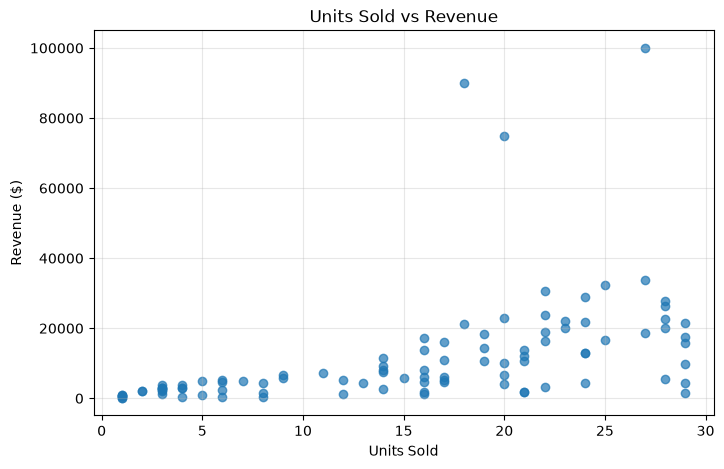

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Units_Sold"], df["Revenue"], alpha=0.7)

plt.xlabel("Units Sold")
plt.ylabel("Revenue ($)")
plt.title("Units Sold vs Revenue")

plt.grid(alpha=0.3)
plt.show()

### Scatter Plot Insight

The scatter plot shows the relationship between units sold and revenue. In general, higher units sold tend to be associated with higher revenue. However, the relationship is not perfectly linear because revenue is also affected by unit price and discount. A few very large revenue values are visible and may represent outliers.

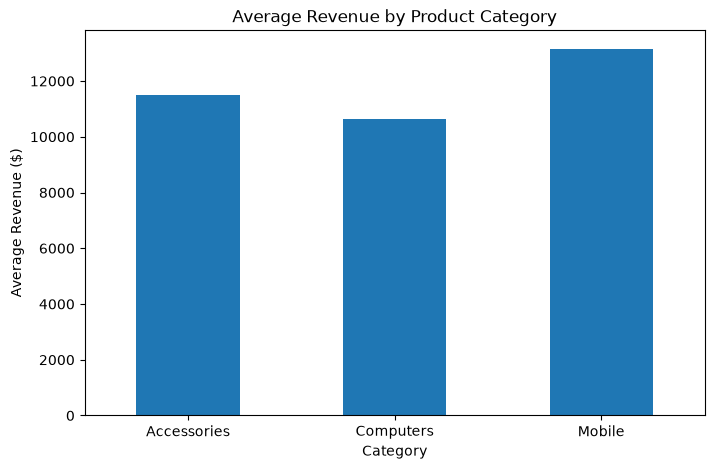

In [7]:
category_revenue = df.groupby("Category")["Revenue"].mean()

plt.figure(figsize=(8, 5))

category_revenue.plot(kind="bar")

plt.xlabel("Category")
plt.ylabel("Average Revenue ($)")
plt.title("Average Revenue by Product Category")

plt.xticks(rotation=0)
plt.show()

### Bar Chart Insight

The bar chart compares average revenue across product categories. Differences in average revenue suggest that some categories tend to generate more revenue than others. These differences may be influenced by factors such as product price, units sold, and discount levels.

## Step 3: Data Preprocessing

### 3.1 Handling Missing Values

Missing values are first identified, then appropriate replacement techniques are applied.

In [8]:
print("Missing values before preprocessing:")
print(df.isnull().sum())

Missing values before preprocessing:
Date               0
Product            0
Category           0
Region             0
Units_Sold         0
Unit_Price         2
Customer_Rating    4
Discount           0
Revenue            2
dtype: int64


In [9]:
df[df.isnull().any(axis=1)]

,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Discount,Revenue
5,2026-01-06,Phone,Accessories,North,22,876.59,NaN,0.02,18899.28
12,2026-01-13,Headphones,Computers,East,8,NaN,3.5,0.11,NaN
18,2026-01-19,Laptop,Computers,South,16,1224.66,NaN,0.29,13912.14
35,2026-02-05,Headphones,Computers,North,1,NaN,4.4,0.29,NaN
42,2026-02-12,Monitor,Accessories,East,7,807.25,NaN,0.11,5029.17
77,2026-03-19,Monitor,Computers,North,12,566.16,NaN,0.24,5163.38


In [10]:
df_clean = df.copy()

# Fill missing Unit_Price values with the mean
mean_price = df_clean["Unit_Price"].mean()
df_clean["Unit_Price"] = df_clean["Unit_Price"].fillna(mean_price)

# Fill missing Customer_Rating values with the median
median_rating = df_clean["Customer_Rating"].median()
df_clean["Customer_Rating"] = df_clean["Customer_Rating"].fillna(median_rating)

# Recalculate Revenue for rows where it was missing
missing_revenue = df_clean["Revenue"].isna()

df_clean.loc[missing_revenue, "Revenue"] = (
    df_clean.loc[missing_revenue, "Units_Sold"]
    * df_clean.loc[missing_revenue, "Unit_Price"]
    * (1 - df_clean.loc[missing_revenue, "Discount"])
).round(2)

In [11]:
print("Missing values after preprocessing:")
print(df_clean.isnull().sum())

Missing values after preprocessing:
Date               0
Product            0
Category           0
Region             0
Units_Sold         0
Unit_Price         0
Customer_Rating    0
Discount           0
Revenue            0
dtype: int64


In [12]:
df_clean.loc[[5, 12, 18, 35, 42, 77]]

,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Discount,Revenue
5,2026-01-06,Phone,Accessories,North,22,876.590000,3.9,0.02,18899.28
12,2026-01-13,Headphones,Computers,East,8,764.230918,3.5,0.11,5441.32
18,2026-01-19,Laptop,Computers,South,16,1224.660000,3.9,0.29,13912.14
35,2026-02-05,Headphones,Computers,North,1,764.230918,4.4,0.29,542.60
42,2026-02-12,Monitor,Accessories,East,7,807.250000,3.9,0.11,5029.17
77,2026-03-19,Monitor,Computers,North,12,566.160000,3.9,0.24,5163.38


#### Missing Value Handling

Missing values in `Unit_Price` were replaced with the mean unit price. Missing values in `Customer_Rating` were replaced with the median rating. Revenue values that were missing because of missing unit prices were recalculated after the unit prices were filled.

### 3.2 Outlier Detection and Removal

The Interquartile Range (IQR) method is used to identify unusually high or low revenue values.

In [13]:
Q1 = df_clean["Revenue"].quantile(0.25)
Q3 = df_clean["Revenue"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 2532.01
Q3: 16041.57
IQR: 13509.56
Lower Bound: -17732.33
Upper Bound: 36305.91


In [14]:
outliers = df_clean[
    (df_clean["Revenue"] < lower_bound) |
    (df_clean["Revenue"] > upper_bound)
]

print("Identified Outliers:")
outliers

Identified Outliers:


,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Discount,Revenue
3,2026-01-04,Headphones,Computers,South,20,1407.42,2.6,0.00,75000.0
25,2026-01-26,Tablet,Accessories,West,18,1067.85,4.5,0.29,90000.0
60,2026-03-02,Phone,Mobile,West,27,1445.84,3.9,0.26,100000.0


In [15]:
df_no_outliers = df_clean[
    (df_clean["Revenue"] >= lower_bound) &
    (df_clean["Revenue"] <= upper_bound)
].copy()

print("Dataset size before removing outliers:", df_clean.shape)
print("Dataset size after removing outliers:", df_no_outliers.shape)

df_no_outliers.head()

Dataset size before removing outliers: (100, 9)
Dataset size after removing outliers: (97, 9)


,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Discount,Revenue
0,2026-01-01,Monitor,Accessories,West,16,509.54,2.9,0.27,5951.43
1,2026-01-02,Headphones,Computers,East,16,295.76,2.7,0.03,4590.20
2,2026-01-03,Tablet,Mobile,East,3,857.36,4.1,0.15,2186.27
4,2026-01-05,Headphones,Accessories,East,24,1059.24,4.0,0.14,21862.71
5,2026-01-06,Phone,Accessories,North,22,876.59,3.9,0.02,18899.28


#### Outlier Handling

Revenue outliers were identified using the IQR method. Values below `Q1 - 1.5 × IQR` or above `Q3 + 1.5 × IQR` were considered outliers and removed from the dataset to reduce the influence of extreme values on later analysis.

### 3.3 Data Reduction

Data reduction is used to reduce the size or dimensionality of a dataset while preserving useful information. In this section, random sampling and column elimination are applied.

In [16]:
print("Dataset shape before reduction:", df_no_outliers.shape)

df_no_outliers.head()

Dataset shape before reduction: (97, 9)


,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Discount,Revenue
0,2026-01-01,Monitor,Accessories,West,16,509.54,2.9,0.27,5951.43
1,2026-01-02,Headphones,Computers,East,16,295.76,2.7,0.03,4590.20
2,2026-01-03,Tablet,Mobile,East,3,857.36,4.1,0.15,2186.27
4,2026-01-05,Headphones,Accessories,East,24,1059.24,4.0,0.14,21862.71
5,2026-01-06,Phone,Accessories,North,22,876.59,3.9,0.02,18899.28


In [17]:
df_sample = df_no_outliers.sample(
    frac=0.70,
    random_state=42
)

print("Dataset shape before sampling:", df_no_outliers.shape)
print("Dataset shape after 70% sampling:", df_sample.shape)

Dataset shape before sampling: (97, 9)
Dataset shape after 70% sampling: (68, 9)


In [18]:
print("Columns before dimension reduction:")
print(df_sample.columns.tolist())

df_reduced = df_sample.drop(columns=["Discount"])

print("\nColumns after dimension reduction:")
print(df_reduced.columns.tolist())

df_reduced.head()

Columns before dimension reduction:
['Date', 'Product', 'Category', 'Region', 'Units_Sold', 'Unit_Price', 'Customer_Rating', 'Discount', 'Revenue']

Columns after dimension reduction:
['Date', 'Product', 'Category', 'Region', 'Units_Sold', 'Unit_Price', 'Customer_Rating', 'Revenue']


,Date,Product,Category,Region,Units_Sold,Unit_Price,Customer_Rating,Revenue
65,2026-03-07,Monitor,Computers,South,28,276.83,4.2,5425.87
42,2026-02-12,Monitor,Accessories,East,7,807.25,3.9,5029.17
96,2026-04-07,Headphones,Computers,West,29,957.50,2.7,21380.98
19,2026-01-20,Monitor,Computers,North,25,1307.25,2.7,32354.44
84,2026-03-26,Laptop,Accessories,South,28,1070.30,4.6,27870.61


#### Data Reduction

A random sample containing 70% of the cleaned dataset was created to demonstrate row reduction. In addition, the `Discount` column was removed to demonstrate dimensionality reduction. These techniques reduce the size and complexity of the dataset while retaining enough information for analysis.

### 3.4 Data Scaling and Discretization

Data scaling transforms numerical values into a common range, while discretization converts continuous numerical values into categories.

In [19]:
print("Revenue values before scaling:")

df_no_outliers[["Revenue"]].head(10)

Revenue values before scaling:


,Revenue
0,5951.43
1,4590.20
2,2186.27
4,21862.71
5,18899.28
6,4398.57
7,904.09
8,28879.68
9,3948.67
10,7230.25


In [20]:
revenue_min = df_no_outliers["Revenue"].min()
revenue_max = df_no_outliers["Revenue"].max()

df_no_outliers["Revenue_Scaled"] = (
    (df_no_outliers["Revenue"] - revenue_min)
    / (revenue_max - revenue_min)
)

df_no_outliers[["Revenue", "Revenue_Scaled"]].head(10)

,Revenue,Revenue_Scaled
0,5951.43,0.174137
1,4590.20,0.133679
2,2186.27,0.062229
4,21862.71,0.647050
5,18899.28,0.558971
6,4398.57,0.127983
7,904.09,0.024120
8,28879.68,0.855608
9,3948.67,0.114611
10,7230.25,0.212146


In [21]:
df_no_outliers["Revenue_Category"] = pd.qcut(
    df_no_outliers["Revenue"],
    q=3,
    labels=["Low", "Medium", "High"]
)

df_no_outliers[
    ["Revenue", "Revenue_Scaled", "Revenue_Category"]
].head(15)

,Revenue,Revenue_Scaled,Revenue_Category
0,5951.43,0.174137,Medium
1,4590.20,0.133679,Medium
2,2186.27,0.062229,Low
4,21862.71,0.647050,High
5,18899.28,0.558971,High
6,4398.57,0.127983,Medium
7,904.09,0.024120,Low
8,28879.68,0.855608,High
9,3948.67,0.114611,Medium
10,7230.25,0.212146,Medium


#### Scaling and Discretization

Min-Max Scaling was applied to the `Revenue` column to transform the values into a range between 0 and 1. This technique is useful when numerical variables have different scales.

Revenue was also discretized into three categories: `Low`, `Medium`, and `High`. Quantile-based discretization was used so that the observations were divided into approximately equal-sized groups.

## Step 4: Statistical Analysis

Statistical analysis is used to summarize the main characteristics of the dataset and examine relationships between numerical variables.

### 4.1 General Overview of Data

The `info()` method provides information about the number of rows, columns, data types, and non-null values in the dataset.

The `describe()` method provides summary statistics for numerical variables, including the count, mean, standard deviation, minimum, maximum, and quartile values.

In [22]:
df_no_outliers.info()

<class 'pandas.DataFrame'>
Index: 97 entries, 0 to 99
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Date              97 non-null     datetime64[us]
 1   Product           97 non-null     str           
 2   Category          97 non-null     str           
 3   Region            97 non-null     str           
 4   Units_Sold        97 non-null     int32         
 5   Unit_Price        97 non-null     float64       
 6   Customer_Rating   97 non-null     float64       
 7   Discount          97 non-null     float64       
 8   Revenue           97 non-null     float64       
 9   Revenue_Scaled    97 non-null     float64       
 10  Revenue_Category  97 non-null     category      
dtypes: category(1), datetime64[us](1), float64(5), int32(1), str(3)
memory usage: 8.2 KB


In [23]:
df_no_outliers.describe()

,Date,Units_Sold,Unit_Price,Customer_Rating,Discount,Revenue,Revenue_Scaled
count,97,97.000000,97.000000,97.000000,97.000000,97.000000,97.000000
mean,2026-02-20 02:58:08.659793,14.711340,747.443112,3.794845,0.168763,9122.533299,0.268388
min,2026-01-01 00:00:00,1.000000,70.870000,2.500000,0.000000,92.550000,0.000000
25%,2026-01-27 00:00:00,6.000000,442.710000,3.200000,0.090000,2517.760000,0.072082
50%,2026-02-20 00:00:00,16.000000,791.450000,3.900000,0.180000,5425.870000,0.158516
75%,2026-03-17 00:00:00,22.000000,1059.240000,4.400000,0.250000,14418.480000,0.425794
max,2026-04-10 00:00:00,29.000000,1485.580000,5.000000,0.300000,33737.800000,1.000000
std,NaN,9.176463,393.479175,0.751300,0.091575,8610.369353,0.255916


### 4.2 Central Tendency Measures

Central tendency measures are used to summarize the typical or central values of numerical variables in the dataset.

In [24]:
numeric_columns = [
    "Units_Sold",
    "Unit_Price",
    "Customer_Rating",
    "Discount",
    "Revenue"
]

central_tendency = pd.DataFrame({
    "Minimum": df_no_outliers[numeric_columns].min(),
    "Maximum": df_no_outliers[numeric_columns].max(),
    "Mean": df_no_outliers[numeric_columns].mean(),
    "Median": df_no_outliers[numeric_columns].median(),
    "Mode": df_no_outliers[numeric_columns].mode().iloc[0]
})

central_tendency

,Minimum,Maximum,Mean,Median,Mode
Units_Sold,1.00,29.00,14.711340,16.00,1.000000
Unit_Price,70.87,1485.58,747.443112,791.45,764.230918
Customer_Rating,2.50,5.00,3.794845,3.90,2.700000
Discount,0.00,0.30,0.168763,0.18,0.290000
Revenue,92.55,33737.80,9122.533299,5425.87,92.550000


#### Central Tendency Analysis

The minimum and maximum values show the lowest and highest observations for each numerical variable. The mean represents the average value, while the median represents the middle value when the data is ordered. The mode represents the most frequently occurring value. Comparing these measures helps provide a general understanding of the distribution of each variable.

### 4.3 Dispersion Measures

Dispersion measures describe how spread out the numerical values are within the dataset.

In [25]:
dispersion = pd.DataFrame({
    "Range": (
        df_no_outliers[numeric_columns].max()
        - df_no_outliers[numeric_columns].min()
    ),
    "Q1": df_no_outliers[numeric_columns].quantile(0.25),
    "Q2_Median": df_no_outliers[numeric_columns].quantile(0.50),
    "Q3": df_no_outliers[numeric_columns].quantile(0.75),
    "IQR": (
        df_no_outliers[numeric_columns].quantile(0.75)
        - df_no_outliers[numeric_columns].quantile(0.25)
    ),
    "Variance": df_no_outliers[numeric_columns].var(),
    "Standard_Deviation": df_no_outliers[numeric_columns].std()
})

dispersion

,Range,Q1,Q2_Median,Q3,IQR,Variance,Standard_Deviation
Units_Sold,28.00,6.00,16.00,22.00,16.00,8.420747e+01,9.176463
Unit_Price,1414.71,442.71,791.45,1059.24,616.53,1.548259e+05,393.479175
Customer_Rating,2.50,3.20,3.90,4.40,1.20,5.644523e-01,0.751300
Discount,0.30,0.09,0.18,0.25,0.16,8.385954e-03,0.091575
Revenue,33645.25,2517.76,5425.87,14418.48,11900.72,7.413846e+07,8610.369353


#### Dispersion Analysis

The range shows the difference between the maximum and minimum values. Quartiles divide the data into four parts, while the Interquartile Range (IQR) measures the spread of the middle 50% of the data. Variance and standard deviation show how much the values vary around the mean. Larger values indicate greater variability.

### 4.4 Correlation Analysis

Correlation analysis is used to measure the strength and direction of relationships between numerical variables.

In [26]:
correlation_matrix = df_no_outliers[numeric_columns].corr()

correlation_matrix

,Units_Sold,Unit_Price,Customer_Rating,Discount,Revenue
Units_Sold,1.000000,-0.017783,-0.010946,0.056220,0.697223
Unit_Price,-0.017783,1.000000,0.064272,-0.114911,0.587530
Customer_Rating,-0.010946,0.064272,1.000000,0.011867,0.027424
Discount,0.056220,-0.114911,0.011867,1.000000,-0.165132
Revenue,0.697223,0.587530,0.027424,-0.165132,1.000000


#### Correlation Analysis

The correlation matrix shows the relationships between numerical variables. Correlation values range from -1 to 1. Values close to 1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values close to 0 indicate little or no linear relationship.

Revenue is expected to have a positive relationship with variables such as `Units_Sold` and `Unit_Price`, because increases in those values generally contribute to higher revenue.

In [27]:
df_no_outliers.to_csv("sales_data_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Conclusion

This lab demonstrated the use of Python for data visualization, preprocessing, and statistical analysis. A synthetic sales dataset was created and explored using scatter plots and bar charts.

Missing values were identified and handled using mean and median replacement. Revenue outliers were detected using the Interquartile Range (IQR) method and removed from the dataset. Data reduction was demonstrated through random sampling and column elimination. Min-Max Scaling was applied to revenue, and revenue values were also discretized into Low, Medium, and High categories.

Statistical analysis was performed using summary statistics, measures of central tendency, dispersion measures, and correlation analysis. Overall, the lab showed how preprocessing and statistical techniques can be used to better understand a dataset and prepare it for further data mining or machine learning tasks.